# Generate_Data_v2.5

This notebook upgrades the `v2.4` GP-DDM generator by combining:

- the corrected `S2_gen_data_optimized` baseline logic,
- optional GP residual surfaces for `v` and `a`,
- subject-level random effects,
- realistic trial bookkeeping with explicit invalid/timeout trials,
- quick summary functions for checking SPE, RT, and response patterns.

## Main modeling changes vs v2.4

1. Use the corrected S2 backbone: `GAMMA = 0.1`, `k_min = 0.01`, `k_max = 0.15`.
2. Move boundary variability to the subject level using `A_CV`, instead of large trial-level `a` noise.
3. Keep fixed trial schedules and mark invalid trials explicitly, rather than silently replacing or dropping them.
4. Replace arbitrary GP training targets (`sin/cos`) with an honest residual-GP interface.
5. Add subject random effects and clearer diagnostics for later calibration to empirical data.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, RBF, WhiteKernel

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

BASE_DIR = Path.cwd().parent.parent
OUT_DIR = BASE_DIR / '2_Data' / 'Generate_Data' / 'Generate_Data_v2.5'
FIG_DIR = BASE_DIR / '3_Figures' / 'Generate_Data_v2.5'
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print('Data output:', OUT_DIR)
print('Figure output:', FIG_DIR)

Data output: d:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design\2_Data\Generate_Data\Generate_Data_v2.5
Figure output: d:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design\3_Figures\Generate_Data_v2.5


In [2]:
CONFIG = {
    'seed': 42,
    'P_range': (0, 150),
    'T_range': (10, 600),
    'W_range': (200, 1500),
    'alpha_self': 1.5,
    'alpha_stranger': -0.4,
    'beta_high_M': 0.2,
    'beta_low_M': 0.0,
    'gamma_P': 0.1,
    'P0': 32,
    'P1': 4,
    'k_min': 0.01,
    'k_max': 0.15,
    'T0_center': 100,
    'k_T': 0.01,
    'M0': 600,
    'k_M': 0.01,
    'backbone_scale_v': 3.0,
    'backbone_scale_a': 3.0,
    't0': 0.2,
    'dt': 0.001,
    'A_CV': 0.15,
    'subject_v_sd': 0.20,
    'subject_t0_sd': 0.015,
    'trial_v_sd': 1.0,
    'gp_weight_v': 0.35,
    'gp_weight_a': 0.35,
    'record_invalid_trials': True,
}

In [3]:
def sample_random_ptw(n_subjects, rng, cfg=CONFIG):
    P = rng.integers(cfg['P_range'][0], cfg['P_range'][1], size=n_subjects)
    T = rng.integers(cfg['T_range'][0], cfg['T_range'][1], size=n_subjects)
    W = rng.integers(cfg['W_range'][0], cfg['W_range'][1], size=n_subjects)
    return pd.DataFrame({'subjectID': np.arange(1, n_subjects + 1), 'P': P, 'T': T, 'W': W})


def normalize_ptw(P, T, W):
    Pn = (np.asarray(P, dtype=float) - 75.0) / 75.0
    Tn = (np.asarray(T, dtype=float) - 305.0) / 295.0
    Wn = (np.asarray(W, dtype=float) - 850.0) / 650.0
    return Pn, Tn, Wn


def k_P_func(P, cfg=CONFIG):
    return cfg['k_min'] + (cfg['k_max'] - cfg['k_min']) / (1 + np.exp(-cfg['gamma_P'] * (np.asarray(P) - cfg['P0'])))


def v_P_func(P, cfg=CONFIG):
    k = k_P_func(P, cfg=cfg)
    return 1 / (1 + np.exp(-k * (np.asarray(P) - cfg['P1'])))


def compute_v_backbone(T, P, condition_key, cfg=CONFIG):
    T = np.asarray(T, dtype=float)
    P = np.asarray(P, dtype=float)
    v_T = 1 / (1 + np.exp(-cfg['k_T'] * (T - cfg['T0_center'])))
    v_P = v_P_func(P, cfg=cfg)
    v_0 = v_T * v_P * cfg['backbone_scale_v']
    alpha = np.where(np.asarray(condition_key) == 1, cfg['alpha_self'], cfg['alpha_stranger'])
    return v_0 * (1 + alpha)


def compute_a_backbone(M, cfg=CONFIG):
    M = np.asarray(M, dtype=float)
    a_0 = 1 / (1 + np.exp(-cfg['k_M'] * (M - cfg['M0']))) * cfg['backbone_scale_a']
    beta = np.where(M > cfg['M0'], 1 + cfg['beta_high_M'], 1 + cfg['beta_low_M'])
    return a_0 * beta

In [4]:
class ResidualGPDDM:
    # Residual GP on top of the corrected S2 backbone.
    # If no anchor data are provided, residuals default to zero.

    def __init__(self, random_state=42):
        kernel = ConstantKernel(1.0, (1e-3, 10.0)) * RBF(
            length_scale=[0.7, 0.7, 0.7, 0.7],
            length_scale_bounds=(1e-2, 10.0),
        ) + WhiteKernel(noise_level=1e-4, noise_level_bounds=(1e-6, 1.0))
        self.gp_v = GaussianProcessRegressor(kernel=kernel, normalize_y=True, random_state=random_state)
        self.gp_a = GaussianProcessRegressor(kernel=kernel, normalize_y=True, random_state=random_state)
        self.is_fitted = False

    def _make_X(self, anchor_df):
        Pn, Tn, Wn = normalize_ptw(anchor_df['P'].to_numpy(), anchor_df['T'].to_numpy(), anchor_df['W'].to_numpy())
        ck = anchor_df['condition_key'].to_numpy(dtype=float)
        return np.column_stack([Pn, Tn, Wn, ck])

    def fit(self, anchor_df):
        required = {'P', 'T', 'W', 'condition_key', 'v_resid', 'a_resid'}
        missing = required.difference(anchor_df.columns)
        if missing:
            raise ValueError(f'Missing anchor columns: {sorted(missing)}')
        X = self._make_X(anchor_df)
        self.gp_v.fit(X, anchor_df['v_resid'].to_numpy(dtype=float))
        self.gp_a.fit(X, anchor_df['a_resid'].to_numpy(dtype=float))
        self.is_fitted = True
        return self

    def predict(self, P, T, W, condition_key):
        P = np.atleast_1d(P)
        T = np.atleast_1d(T)
        W = np.atleast_1d(W)
        condition_key = np.atleast_1d(condition_key).astype(float)
        Pn, Tn, Wn = normalize_ptw(P, T, W)
        X = np.column_stack([Pn, Tn, Wn, condition_key])
        if not self.is_fitted:
            zeros = np.zeros(len(X), dtype=float)
            return zeros, zeros, zeros, zeros
        v_resid, v_std = self.gp_v.predict(X, return_std=True)
        a_resid, a_std = self.gp_a.predict(X, return_std=True)
        return v_resid, a_resid, v_std, a_std


def build_example_anchor_df(cfg=CONFIG, rng=None):
    # Demo anchors only. Replace with empirical residual summaries when available.
    if rng is None:
        rng = np.random.default_rng(cfg['seed'])

    grid = []
    for P in [0, 8, 30, 60, 120, 149]:
        for T in [30, 80, 120, 300, 500, 599]:
            for W in [300, 600, 800, 1100, 1400, 1499]:
                for condition_key in [0, 1]:
                    Pn, Tn, Wn = normalize_ptw(P, T, W)
                    v_resid = 0.12 * condition_key / (1 + np.exp(-2.2 * Pn)) - 0.04 * Wn + rng.normal(0, 0.02)
                    a_resid = 0.06 / (1 + np.exp(-1.8 * Wn)) - 0.03 * condition_key + rng.normal(0, 0.015)
                    grid.append({
                        'P': P,
                        'T': T,
                        'W': W,
                        'condition_key': condition_key,
                        'v_resid': v_resid,
                        'a_resid': a_resid,
                    })
    return pd.DataFrame(grid)

In [5]:
def simulate_single_trial_fast(v, a, t0, max_time_s, dt=0.001, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    max_steps = max(1, int(np.floor(max_time_s / dt)))
    noise = rng.normal(0.0, np.sqrt(dt), size=max_steps)
    evidence = a / 2.0 + np.cumsum(v * dt + noise)

    upper = np.flatnonzero(evidence >= a)
    lower = np.flatnonzero(evidence <= 0)

    if len(upper) and len(lower):
        idx = upper[0] if upper[0] < lower[0] else lower[0]
        response = 1 if upper[0] < lower[0] else 2
        return t0 + (idx + 1) * dt, response, True
    if len(upper):
        return t0 + (upper[0] + 1) * dt, 1, True
    if len(lower):
        return t0 + (lower[0] + 1) * dt, 2, True
    return t0 + max_steps * dt, 0, False


def build_subject_effects(subject_df, rng=None, cfg=CONFIG):
    if rng is None:
        rng = np.random.default_rng(cfg['seed'])
    df = subject_df.copy()
    df['M'] = df['T'] + df['W']
    a_base = compute_a_backbone(df['M'].to_numpy(), cfg=cfg)
    df['a_subject'] = np.maximum(0.05, a_base * rng.normal(1.0, cfg['A_CV'], size=len(df)))
    df['v_subject_shift'] = rng.normal(0.0, cfg['subject_v_sd'], size=len(df))
    df['t0_subject'] = np.maximum(0.05, cfg['t0'] + rng.normal(0.0, cfg['subject_t0_sd'], size=len(df)))
    return df

In [6]:
def generate_dataset_v2_5(
    n_subjects=200,
    trials_per_subject=60,
    subject_ptw=None,
    gp_model=None,
    use_example_anchors=False,
    seed=None,
    cfg=CONFIG,
):
    rng = np.random.default_rng(cfg['seed'] if seed is None else seed)

    if subject_ptw is None:
        subject_ptw = sample_random_ptw(n_subjects=n_subjects, rng=rng, cfg=cfg)
    else:
        subject_ptw = subject_ptw.copy()
        if 'subjectID' not in subject_ptw.columns:
            subject_ptw = subject_ptw.reset_index(drop=True)
            subject_ptw['subjectID'] = np.arange(1, len(subject_ptw) + 1)

    subject_df = build_subject_effects(subject_ptw[['subjectID', 'P', 'T', 'W']], rng=rng, cfg=cfg)

    if gp_model is None:
        gp_model = ResidualGPDDM(random_state=cfg['seed'])
        if use_example_anchors:
            gp_model.fit(build_example_anchor_df(cfg=cfg, rng=rng))

    rows = []
    trials_per_condition = trials_per_subject // 2
    if trials_per_subject % 2 != 0:
        trials_per_condition += 1

    for row in subject_df.itertuples(index=False):
        max_time_s = (row.W + row.T - row.t0_subject * 1000) * 0.001 + cfg['dt']
        max_time_s = max(max_time_s, row.t0_subject + cfg['dt'])

        for condition_key, label in [(0, 'stranger'), (1, 'self')]:
            v_backbone = float(compute_v_backbone(row.T, row.P, condition_key, cfg=cfg))
            v_resid, a_resid, v_std, a_std = gp_model.predict(row.P, row.T, row.W, condition_key)
            v_center = (1 - cfg['gp_weight_v']) * v_backbone + cfg['gp_weight_v'] * (v_backbone + float(v_resid[0]))
            a_center = (1 - cfg['gp_weight_a']) * row.a_subject + cfg['gp_weight_a'] * max(0.05, row.a_subject + float(a_resid[0]))

            for trial in range(1, trials_per_condition + 1):
                v_trial = rng.normal(v_center + row.v_subject_shift, cfg['trial_v_sd'])
                a_trial = max(0.05, a_center)
                rt, response, is_valid = simulate_single_trial_fast(
                    v=v_trial,
                    a=a_trial,
                    t0=row.t0_subject,
                    max_time_s=max_time_s,
                    dt=cfg['dt'],
                    rng=rng,
                )

                trial_row = {
                    'subjectID': row.subjectID,
                    'trialID': trial,
                    'P': row.P,
                    'T': row.T,
                    'W': row.W,
                    'M': row.M,
                    'Label': label,
                    'condition_key': condition_key,
                    'v_backbone': v_backbone,
                    'a_backbone_subject': row.a_subject,
                    'v_gp_resid': float(v_resid[0]),
                    'a_gp_resid': float(a_resid[0]),
                    'v_gp_std': float(v_std[0]) if np.ndim(v_std) else float(v_std),
                    'a_gp_std': float(a_std[0]) if np.ndim(a_std) else float(a_std),
                    'v_subject_shift': row.v_subject_shift,
                    'v': v_trial,
                    'a': a_trial,
                    't0': row.t0_subject,
                    'z': a_trial / 2.0,
                    'RT': rt,
                    'response': response,
                    'is_valid': bool(is_valid),
                    'is_timeout': bool(not is_valid),
                    'max_time_s': max_time_s,
                }

                if cfg['record_invalid_trials'] or is_valid:
                    rows.append(trial_row)

    df = pd.DataFrame(rows)
    return df, gp_model, subject_df

In [7]:
def summarize_dataset(df):
    out = {}
    valid = df[df['is_valid']].copy()
    out['n_rows'] = len(df)
    out['n_valid'] = len(valid)
    out['n_subjects'] = df['subjectID'].nunique()
    out['valid_rate'] = valid.shape[0] / max(len(df), 1)
    out['mean_rt_s'] = valid['RT'].mean()
    out['median_rt_s'] = valid['RT'].median()
    out['upper_rate'] = (valid['response'] == 1).mean()
    out['lower_rate'] = (valid['response'] == 2).mean()

    subj = valid.groupby(['subjectID', 'Label'])['RT'].mean().reset_index()
    wide = subj.pivot(index='subjectID', columns='Label', values='RT').dropna()
    if {'self', 'stranger'}.issubset(wide.columns):
        wide['SPE_ms'] = (wide['self'] - wide['stranger']) * 1000
        out['mean_spe_ms'] = wide['SPE_ms'].mean()
        out['sd_spe_ms'] = wide['SPE_ms'].std(ddof=1)
    else:
        out['mean_spe_ms'] = np.nan
        out['sd_spe_ms'] = np.nan
    return pd.Series(out)


def plot_quick_checks(df, fig_dir=FIG_DIR, stem='v2_5'):
    valid = df[df['is_valid']].copy()

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    axes[0].hist(valid['RT'] * 1000, bins=50, edgecolor='black')
    axes[0].set_title('RT distribution (ms)')
    axes[0].set_xlabel('RT (ms)')

    for label in ['self', 'stranger']:
        subset = valid.loc[valid['Label'] == label, 'RT'] * 1000
        axes[1].hist(subset, bins=35, alpha=0.5, label=label, edgecolor='black')
    axes[1].legend()
    axes[1].set_title('RT by label (ms)')
    axes[1].set_xlabel('RT (ms)')

    subj = valid.groupby(['subjectID', 'Label'])['RT'].mean().reset_index()
    wide = subj.pivot(index='subjectID', columns='Label', values='RT').dropna()
    if {'self', 'stranger'}.issubset(wide.columns):
        spe_ms = (wide['self'] - wide['stranger']) * 1000
        axes[2].hist(spe_ms, bins=30, edgecolor='black')
        axes[2].set_title('Subject-level SPE (ms)')
        axes[2].set_xlabel('self - stranger (ms)')
    else:
        axes[2].text(0.5, 0.5, 'No paired self/stranger data', ha='center', va='center')
        axes[2].set_axis_off()

    plt.tight_layout()
    out_path = fig_dir / f'{stem}_quick_checks.png'
    plt.savefig(out_path, dpi=200, bbox_inches='tight')
    plt.show()
    return out_path

## Optional GP anchor fitting

If you already have empirical parameter-recovery summaries, prepare a dataframe with columns:

- `P`, `T`, `W`
- `condition_key` (`0=stranger`, `1=self`)
- `v_resid`, `a_resid`

These residuals should be the difference between empirical estimates and the corrected S2 backbone.
If you do not fit a GP, residuals default to zero and the generator behaves as a corrected non-GP backbone with random effects.

In [8]:
USE_EXAMPLE_GP_ANCHORS = True

if USE_EXAMPLE_GP_ANCHORS:
    anchor_df = build_example_anchor_df(rng=np.random.default_rng(CONFIG['seed']))
    gp_model = ResidualGPDDM(random_state=CONFIG['seed']).fit(anchor_df)
    print('Example anchors fitted:', anchor_df.shape)
else:
    anchor_df = None
    gp_model = ResidualGPDDM(random_state=CONFIG['seed'])
    print('No GP anchors fitted. Residuals will be zero.')

c:\Users\蔡振辛\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 3 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Example anchors fitted: (432, 6)


c:\Users\蔡振辛\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 3 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


In [12]:
sim_df, gp_model, subject_df = generate_dataset_v2_5(
    n_subjects=2000,
    trials_per_subject=60,
    gp_model=gp_model,
    seed=CONFIG['seed'],
)

summary = summarize_dataset(sim_df)
print(summary)
sim_df.head()

n_rows         120000.000000
n_valid         88253.000000
n_subjects       2000.000000
valid_rate          0.735442
mean_rt_s           0.590390
median_rt_s         0.515592
upper_rate          0.952500
lower_rate          0.047500
mean_spe_ms      -258.960680
sd_spe_ms         174.926229
dtype: float64


,subjectID,trialID,P,T,W,M,Label,condition_key,v_backbone,a_backbone_subject,...,v_subject_shift,v,a,t0,z,RT,response,is_valid,is_timeout,max_time_s
0,1,1,13,528,612,1140,stranger,0,0.999821,4.151697,...,0.10726,0.784849,4.157861,0.202848,2.07893,1.140848,0,False,True,0.938152
1,1,2,13,528,612,1140,stranger,0,0.999821,4.151697,...,0.10726,1.793406,4.157861,0.202848,2.07893,1.140848,0,False,True,0.938152
2,1,3,13,528,612,1140,stranger,0,0.999821,4.151697,...,0.10726,0.556975,4.157861,0.202848,2.07893,1.140848,0,False,True,0.938152
3,1,4,13,528,612,1140,stranger,0,0.999821,4.151697,...,0.10726,1.106508,4.157861,0.202848,2.07893,1.140848,0,False,True,0.938152
4,1,5,13,528,612,1140,stranger,0,0.999821,4.151697,...,0.10726,0.294340,4.157861,0.202848,2.07893,1.140848,0,False,True,0.938152


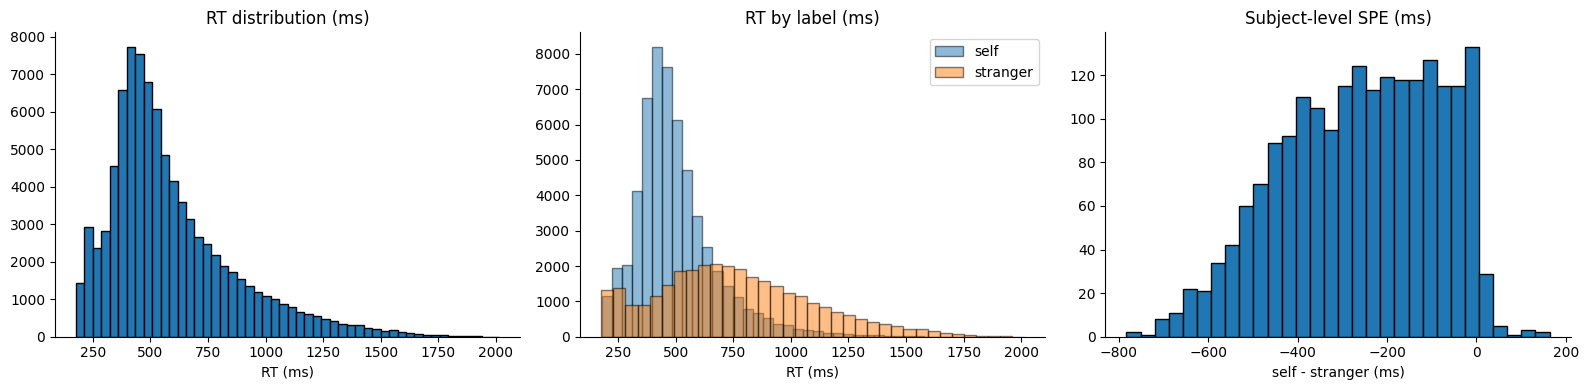

Saved figure to: d:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design\3_Figures\Generate_Data_v2.5\generate_data_v2_5_demo_quick_checks.png


In [13]:
fig_path = plot_quick_checks(sim_df, stem='generate_data_v2_5_demo')
print('Saved figure to:', fig_path)

In [14]:
out_csv = OUT_DIR / 'gp_ddm_v2.5_demo.csv'
sim_df.to_csv(out_csv, index=False)
subject_df.to_csv(OUT_DIR / 'gp_ddm_v2.5_subjects.csv', index=False)
print('Saved trial data to:', out_csv)
print('Saved subject table to:', OUT_DIR / 'gp_ddm_v2.5_subjects.csv')

Saved trial data to: d:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design\2_Data\Generate_Data\Generate_Data_v2.5\gp_ddm_v2.5_demo.csv
Saved subject table to: d:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design\2_Data\Generate_Data\Generate_Data_v2.5\gp_ddm_v2.5_subjects.csv


## Notes for empirical calibration

For your actual goal of fitting real participants more closely, the recommended next step is:

1. Estimate empirical summaries or recovered DDM parameters by condition and PTW region.
2. Convert them to residuals relative to the corrected S2 backbone.
3. Fit the residual GP with those anchors.
4. Tune these parameters jointly:
   - `gp_weight_v`, `gp_weight_a`
   - `subject_v_sd`, `A_CV`, `subject_t0_sd`
   - `trial_v_sd`
   - possibly `alpha_self`, `alpha_stranger`, `beta_high_M`
5. Score the simulated output against empirical RT, accuracy, SPE, and, if possible, quantiles.

This notebook is meant to be a cleaner starting point for that calibration loop.